## Your Group (*Update this Information*)

Submitted by Group 11:

- Ehsan Attar
- Reihaneh Akbarifard
- Maryam Pours Salman Ahvazi
- Ramin Shahbazi

By submitting this exercise, you confirm the following:

- **All people** listed above **contributed** to this solution
- **No other people** were **involved** in this solution
- **No contents** of this solution were **copied from others** (this includes people, large language models, websites, etc.)

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
H, W = 410, 550 # Image dimensions

**Use in-built cv2 functions for filters, Gaussians, Fourier transforms etc. You do not need to write the operations from scratch.**

## Helper Functions

In [9]:
def make_gradient(H, W):
    """
    Smooth horizontal gradient: pixel value increases linearly from left (0) to right (255).
    """
    row = np.linspace(0, 255, W, dtype=np.float64)
    return np.tile(row, (H, 1))

def make_checkerboard(H, W, tile_size=64):
    """
    Checkerboard pattern with alternating 0/255 tiles of given size.
    Spatial frequency = 1/(2*tile_size) cycles/pixel.
    """
    xs = np.arange(W) // tile_size
    ys = np.arange(H) // tile_size
    xx, yy = np.meshgrid(xs, ys)
    return ((xx + yy) % 2) * 255.0

In [10]:
def read_image(filename, format='gray'):
    """
    Read image from file and convert to specified format.
    """
    basepath = os.path.curdir
    img = cv2.imread(os.path.join(basepath, 'data', 'input', filename))
    if format == 'gray':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif format == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (W, H))
    return img.astype(np.float64)

In [11]:
def psnr(image_true: np.ndarray, image_noisy: np.ndarray) -> float:
    """
    Compute Peak Signal-to-Noise Ratio (PSNR) between two images.
    PSNR = 20 * log10(MAX) - 10 * log10(MSE)

    Parameters:
    image_true: clean reference image
    image_noisy: distorted/filtered image (same shape and dtype)

    Returns:
    PSNR in decibels (dB). Returns np.inf if the images are identical.
    """
    image_true  = image_true.astype(np.float64)
    image_noisy = image_noisy.astype(np.float64)

    mse = np.mean((image_true - image_noisy) ** 2)
    if mse == 0:
        return np.inf

    max_val = 255.0 if image_true.max() > 1.0 else 1.0
    return 20 * np.log10(max_val) - 10 * np.log10(mse)

In [12]:
f1 = make_gradient(H, W)        # smooth gradient
f2 = make_checkerboard(H, W)  # checkerboard pattern
f3 = read_image('natural_image.jpg')  # natural image
f4 = read_image('flower.jpg')    # noisy version of natural image

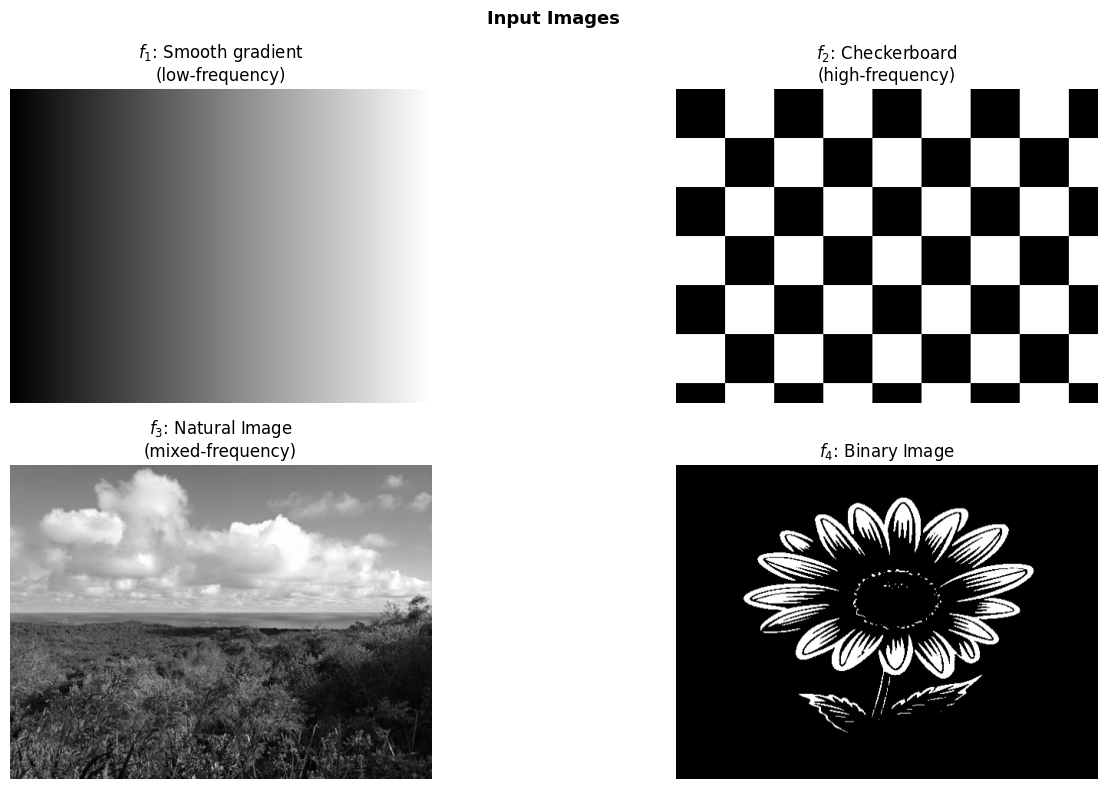

f1 shape: (410, 550), dtype: float64, range: [0.0, 255.0]
f2 shape: (410, 550), dtype: float64, range: [0.0, 255.0]
f3 shape: (410, 550), dtype: float64, range: [0.0, 255.0]
f4 shape: (410, 550), dtype: float64, range: [0.0, 255.0]


In [13]:
# Visualise the input images
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes[0, 0].imshow(f1, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('$f_1$: Smooth gradient\n(low-frequency)', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(f2, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('$f_2$: Checkerboard\n(high-frequency)', fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(f3, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('$f_3$: Natural Image\n(mixed-frequency)', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(f4, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('$f_4$: Binary Image', fontsize=12)
axes[1, 1].axis('off')

plt.suptitle('Input Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'f1 shape: {f1.shape}, dtype: {f1.dtype}, range: [{f1.min():.1f}, {f1.max():.1f}]')
print(f'f2 shape: {f2.shape}, dtype: {f2.dtype}, range: [{f2.min():.1f}, {f2.max():.1f}]')
print(f'f3 shape: {f3.shape}, dtype: {f3.dtype}, range: [{f3.min():.1f}, {f3.max():.1f}]')
print(f'f4 shape: {f4.shape}, dtype: {f4.dtype}, range: [{f4.min():.1f}, {f4.max():.1f}]')

## Question 1: Filters and the Superposition Principle
The goal of this question is to verify superposition experimentally and understand what it means for filter composition and kernel design.

### (1a) Verify the superposition property of the Gaussian filter.

You are given two grayscale images **f1** and **f2**. 

1. Apply a Gaussian filter $G_\sigma$ to each, then verify: $G_\sigma[\alpha f_1 + \beta f_2] = \alpha \cdot G_\sigma[f_1] + \beta \cdot G_\sigma[f_2]$

2. Visualize each component. 

3. Compute the pixel-wise difference between the left and right side. What do you observe? How does the $\sigma$ affect the kernel size?

Maximum difference: 2.2737367544323206e-13
Mean difference: 2.7305541912297998e-14


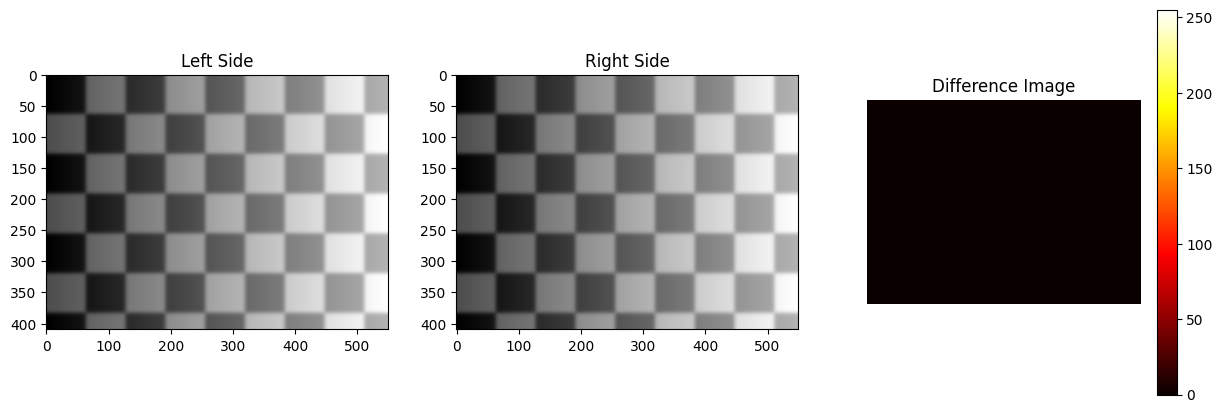

In [14]:
KSIZE = (0, 0) # Let OpenCV compute the kernel size based on sigma

alpha = 0.7
beta = 0.3
sigma = 3

#Left side of equation
combined = alpha * f1 + beta * f2
lhs = cv2.GaussianBlur(combined, KSIZE, sigma)

#Right side of equation
g1 = cv2.GaussianBlur(f1, KSIZE, sigma)
g2 = cv2.GaussianBlur(f2, KSIZE, sigma)
rhs = alpha * g1 + beta * g2

diff = np.abs(lhs - rhs)
print("Maximum difference:", diff.max())
print("Mean difference:", diff.mean())

#Visualize each component
fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(lhs, cmap='gray')
axes[0].set_title('Left Side')

axes[1].imshow(rhs, cmap='gray')
axes[1].set_title('Right Side')

#Compute pixel-wise difference
#We use hot colormap for difference to see it more clearly
#Black -> Very small difference/ Orange and yellow -> Large difference
#It would be black because we have superposition and the difference is zero
plt.imshow(diff, cmap='hot', vmin=0, vmax=255)
plt.colorbar()
plt.title("Difference Image")
plt.axis("off")
plt.show()


#Increasing sigma increases the amount of blur and results in a larger effective kernel size
#because more neighboring pixels contribute to the filtering process.

### (1b) Filter combination

Implement the following two-step pipeline sequentially on **f3**:

1. Apply a Gaussian blur with $\sigma = 1.5$
2. Apply a sharpening (unsharp mask) with $\alpha = 1.0$

Then, using the algebra from the lecture, derive the **single equivalent kernel** $k = (1+\alpha)e - \alpha G_\sigma$​ and apply it in one convolution step. 

Show that the outputs are identical (up to floating point tolerance). Compare the runtime of both approaches.

### (1c) Median filter
Repeat the superposition experiment from 1(a), but now with a median filter. Compute:

$\text{Median}[\alpha f_1 + \beta f_2] \quad \text{vs.} \quad \alpha \cdot \text{Median}[f_1] + \beta \cdot \text{Median}[f_2]$

Visualize the difference image. Is superposition satisfied? Where are the largest differences spatially, at edges, or in flat regions? Why?

## Question 2: Understanding and Handling Noise

The goal here is to understand filters across noise types and content types.

### (2a) Noise robustness comparison

Corrupt the grayscale image **f3** with three noise types:

* Gaussian noise (use np.random.normal)
* Salt-and-pepper noise (randomly set pixels to 0 or 255)
* Impulse noise (randomly set pixels to 255 only)

Apply both a Gaussian filter and a median filter to each noisy image.

Visualize each noise type × filter and discuss: which filter is suitable for which noise type, and why based on the properties of each filter?

Compute PSNR (peak signal-to-noise ratio) against the clean original for all combinations. Validate you observations (Higher the PSNR value, lower the noise).

### (2b) Morphological filters for noise removal 

Corrupt **f4** with salt-and-pepper noise. Apply morphological opening, closing, and opening+closing using structuring elements of 2 different sizes. 

Answer:

* Which operation is necessary for salt noise, and pepper noise individually and combined?
* What happens to fine image structures as structuring element size increases?
* Can you combine morphological filtering with a subsequent Gaussian to further improve quality? Try it and show the result.

## Question 3 - Fourier Transformations

The goal here is to understand the effects of Fourier transforms and operations in the Fourier space.

### (3a) Fourier Transform

Compute the 2D Fourier Transform of **f2** and **f3**. Visualize the log magnitude spectrum of both.
1. What differences do you observe between the frequency spectra of the checkerboard and the natural image?
2. What does this tell you about their spatial structure?

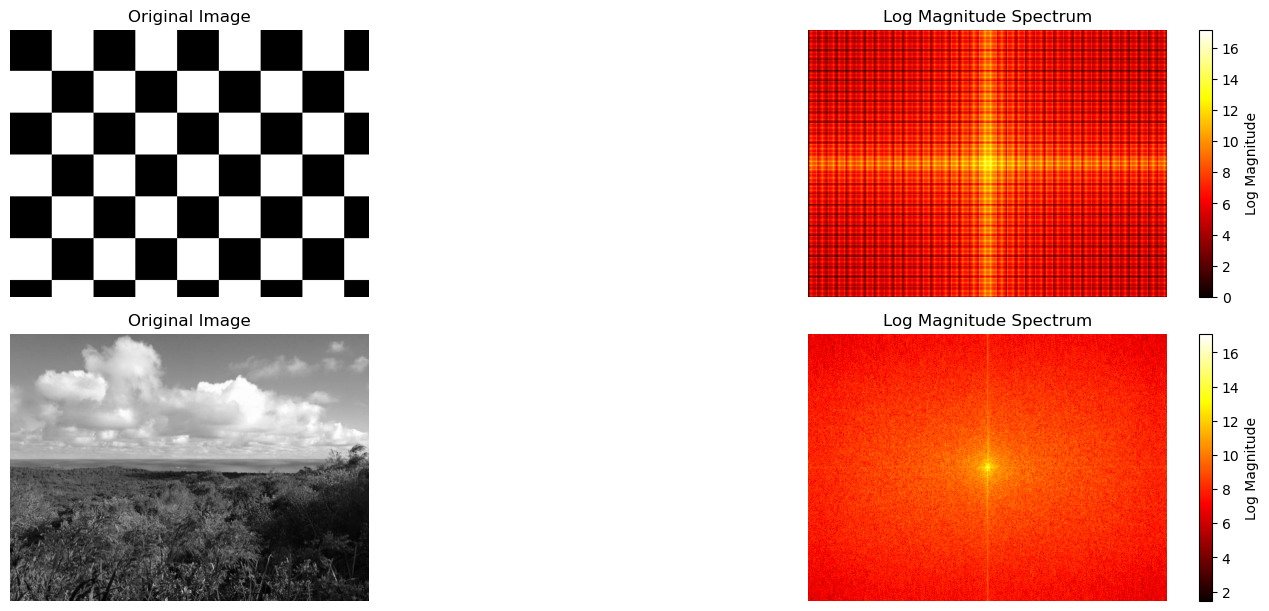

In [135]:
def ft_log_magnitude(img):
    ft = cv2.dft(img, flags=cv2.DFT_COMPLEX_OUTPUT)
    ft_shift = np.fft.fftshift(ft)
    magnitude = cv2.magnitude(ft_shift[:,:,0], ft_shift[:,:,1])
    return np.log1p(magnitude)

fig, axes = plt.subplots(2, 2, figsize=(14, 6), constrained_layout=True)

# first row: f2
axes[0, 0].imshow(f2, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

im = axes[0, 1].imshow(ft_log_magnitude(f2), cmap='hot')
axes[0, 1].set_title('Log Magnitude Spectrum')
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1], label='Log Magnitude')

# second row: f3
axes[1, 0].imshow(f3, cmap='gray')
axes[1, 0].set_title('Original Image')
axes[1, 0].axis('off')

im = axes[1, 1].imshow(ft_log_magnitude(f3), cmap='hot')
axes[1, 1].set_title('Log Magnitude Spectrum')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1], label='Log Magnitude')

plt.show()

1. The checkerboard produces discrete spectral impulses arranged in a regular grid, while the natural image shows a smooth radial falloff with energy concentrated at low frequencies.
2. The checkerboard has a perfectly periodic, repetitive spatial structure, while the natural image contains aperiodic, multi-scale structure with dominant coarse features and progressively less energy at finer scales.

### (3b) Effect of Gaussian Blur

Apply Gaussian blur to both images **f2** and **f3**. Compute and visualize their log magnitude spectrum again.
1. How does Gaussian blur affect the frequency spectrum?
2. Exlain why these changes occur in frequency space.

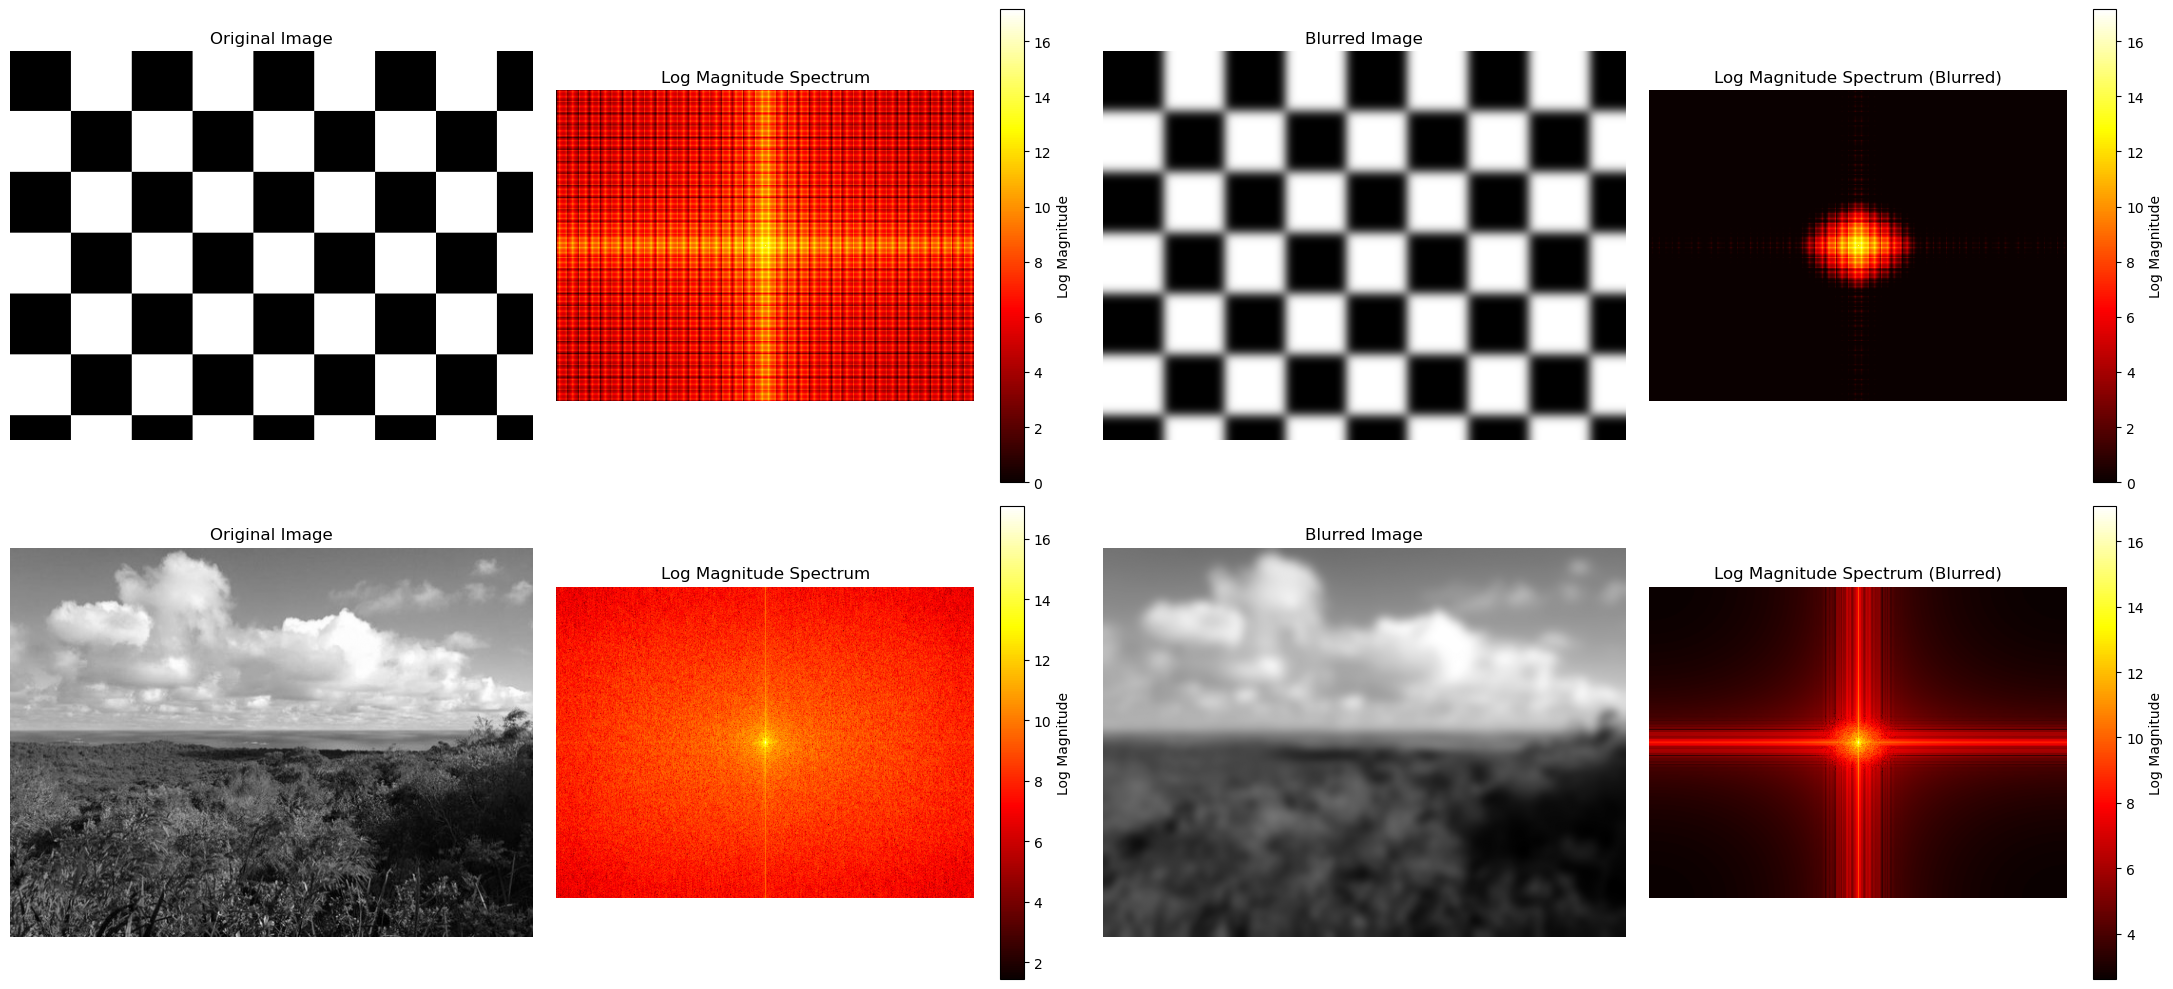

In [134]:
blurred_f2 = cv2.GaussianBlur(f2, (0, 0), 5)
blurred_f3 = cv2.GaussianBlur(f3, (0, 0), 5)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# first row: f2
axes[0, 0].imshow(f2, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

im = axes[0, 1].imshow(ft_log_magnitude(f2), cmap='hot')
axes[0, 1].set_title('Log Magnitude Spectrum')
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1], label='Log Magnitude')

axes[0, 2].imshow(blurred_f2, cmap='gray')
axes[0, 2].set_title('Blurred Image')
axes[0, 2].axis('off')

im = axes[0, 3].imshow(ft_log_magnitude(blurred_f2), cmap='hot')
axes[0, 3].set_title('Log Magnitude Spectrum (Blurred)')
axes[0, 3].axis('off')
plt.colorbar(im, ax=axes[0, 3], label='Log Magnitude')

# second row: f3
axes[1, 0].imshow(f3, cmap='gray')
axes[1, 0].set_title('Original Image')
axes[1, 0].axis('off')

im = axes[1, 1].imshow(ft_log_magnitude(f3), cmap='hot')
axes[1, 1].set_title('Log Magnitude Spectrum')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1], label='Log Magnitude')

axes[1, 2].imshow(blurred_f3, cmap='gray')
axes[1, 2].set_title('Blurred Image')
axes[1, 2].axis('off')

im = axes[1, 3].imshow(ft_log_magnitude(blurred_f3), cmap='hot')
axes[1, 3].set_title('Log Magnitude Spectrum (Blurred)')
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], label='Log Magnitude')

plt.tight_layout()
plt.show()

1. Gaussian blur suppresses high-frequency components in both images, leaving energy tightly concentrated near the center of the spectrum.
2. Because blur is a low-pass filter, and convolution in space equals multiplication in frequency — so the Gaussian simply multiplies away the high frequencies.

### (3c) Frequency Filtering
Apply to both images:
* Low-pass filter
* High-pass filter

Observe and analyse:
1. Changes in spatial domain
2. Changes in frequency domain

In [128]:
def low_pass_filter(img, sigma=1):
    ft = np.fft.fft2(img)
    fshift = np.fft.fftshift(ft)
    rows, cols = img.shape
    kernel = np.zeros(rows * cols, dtype=np.complex128)
    cv2.circle(kernel, (cols // 2, rows // 2), int(cols * sigma), 1, -1)
    kernel = kernel / kernel.sum()
    ft_filtered = fshift * kernel
    ft_filtered = np.fft.ifftshift(ft_filtered)
    return np.fft.ifft2(ft_filtered).real

### (3d) Phase vs Magnitude
Reconstruct the original images **f2** and **f3** using:
* Original FFT (magnitude + phase) 
* Phase only (constant magnitude)
* Magnitude only (random phase)

Cross swap:
* Magnitude of **f3** + Phase of **f2**
* Magnitude of **f2** + Phase of **f3**

1. Which component (phase or magnitude) better preserves image structure?
2. Justify using your results.